<a href="https://colab.research.google.com/github/kshitijagame-tech/data-cleaning-visualization-project/blob/main/customer_churn_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer-churn-training.csv to customer-churn-training.csv


In [ ]:
import pandas as pd

df = pd.read_csv("customer-churn-training.csv")

df.head()

,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (12, 7)

Column Names:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        12 non-null     object
 1   tenure_months      12 non-null     int64 
 2   support_tickets    12 non-null     int64 
 3   monthly_spend_inr  12 non-null     int64 
 4   last_login_days    12 non-null     int64 
 5   plan_type          12 non-null     object
 6   churned            12 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 804.0+ bytes


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate 97s,ztaRows:")
print(df.duplicated().sum())

Missing Values:
customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64

Duplicate Rows:
0


Churn Distribution:
churned
0    7
1    5
Name: count, dtype: int64


NameError: name 'plt' is not defined

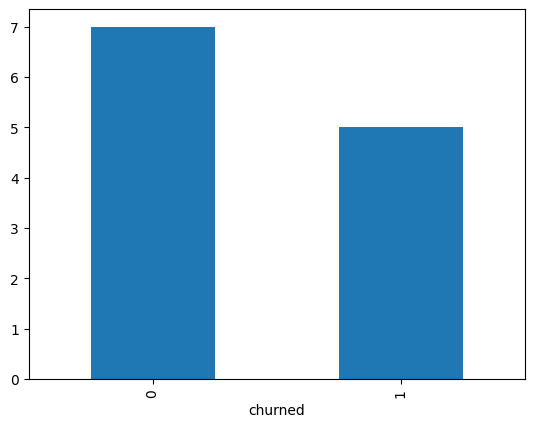

In [ ]:
print("Churn Distribution:")
print(df["churned"].value_counts())

df["churned"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

Churn Distribution:
churned
0    7
1    5
Name: count, dtype: int64


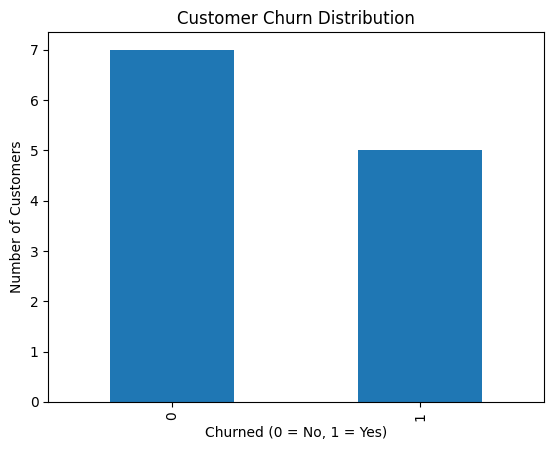

In [ ]:
print("Churn Distribution:")
print(df["churned"].value_counts())

df["churned"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
X = df.drop(columns=["customer_id", "churned"])
y = df["churned"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type
0,2,4,499,21,Basic
1,18,1,1299,2,Pro
2,6,3,799,14,Basic
3,30,0,1499,1,Pro
4,11,2,999,5,Standard



Target:


,churned
0,1
1,0
2,1
3,0
4,0


In [ ]:
numerical_features = ["tenure_months", "support_tickets", "monthly_spend_inr", "last_login_days"]

In [ ]:
categorical_features = ["plan_type"]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure_months',
                                                   'support_tickets',
                                                   'monthly_spend_inr',
                                                   'last_login_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['plan_type'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = model.predict(X_test)

print("Actual:", list(y_test))
print("Predicted:", list(y_pred))

Actual: [0, 1, 1]
Predicted: [np.int64(0), np.int64(1), np.int64(1)]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]


# Responsible Data Card

## Dataset purpose

This dataset may support the identification of customers who could be at risk of churn. It should support human review and retention planning. It must not be used as the only basis for automatic decisions affecting customers.
## Provenance and permission

The dataset was provided as training data for this internship task. The available documentation does not specify how the data was originally collected, who created it, or any consent or licensing details. Therefore, its use should be limited to this educational baseline modeling task unless further permission information is provided.
## Population and representation

Each row represents one customer in the provided training dataset. The dataset contains only a small number of records, so it may not represent the full customer population. Representation across different customer groups cannot be confirmed from the available dataset.
## Features and target

The features used for baseline modeling are tenure_months, support_tickets, monthly_spend_inr, last_login_days, and plan_type.

The target variable is churned, where 1 indicates that a customer churned and 0 indicates that a customer did not churn.

The customer_id field is excluded from modeling because it is only an identifier. Potential leakage should be checked carefully before using any feature in a real-world model.
## Quality checks

The dataset was checked for missing values and duplicate rows. The churn class distribution was also reviewed. Because the dataset contains only 12 records, the train-test split and evaluation results are not sufficient for reliable real-world conclusions.
## Risks and safeguards

Potential risks include biased predictions, privacy concerns, misuse of predictions, false positives, and false negatives.

Safeguards include using the model only as decision support, keeping humans involved in important decisions, monitoring model performance, and avoiding automatic high-impact actions based only on model predictions.
## Intended evaluation

The baseline model will be evaluated using accuracy, precision, recall, and a confusion matrix. Error analysis should examine false positives and false negatives. Because the dataset is very small, the evaluation is only for demonstrating the machine learning workflow and not for real-world deployment.

1. Business Decision
The business wants to identify customers who may be at risk of churn so that the retention team can review these customers and take appropriate actions.
2. Prediction Target
The prediction target is churned.
1 = Customer churned
0 = Customer did not churn
The model predicts whether a customer may belong to the churned class.
3. Unit of Observation
Each row in the dataset represents one customer.
4. Input Features
The baseline model uses:
tenure_months
support_tickets
monthly_spend_inr
last_login_days
plan_type
The customer_id column is excluded because it is only an identifier.
5. Is Machine Learning Justified?
Machine learning may be useful because customer churn can depend on multiple factors such as tenure, support activity, spending, login activity, and subscription plan.
However, the current dataset contains only 12 records. Therefore, this ML model should be treated only as an educational baseline and not as a production-ready system.
6. Non-ML Baseline
A simple rule-based approach could flag customers who:
Have very low tenure.
Have not logged in for many days.
Have a high number of support tickets.
The ML model can be compared with this simple baseline approach.
7. Model Evaluation Metrics
The baseline model is evaluated using:
Accuracy
Precision
Recall
Confusion Matrix
Accuracy alone should not be used for important business decisions because false positives and false negatives can have different costs.
8. False Positive Risk
A false positive occurs when the model predicts that a customer will churn, but the customer does not actually churn.
Possible impacts include unnecessary retention efforts, unnecessary discounts, and additional operational costs.
9. False Negative Risk
A false negative occurs when the model predicts that a customer will not churn, but the customer actually churns.
Possible impacts include losing a customer, losing future revenue, and missing an opportunity for retention.
10. Human Review
The model should be used as a decision-support tool. Human review should be involved before taking important actions based on model predictions.
11. Monitoring
The system should monitor:
Data quality
Missing values
Changes in customer behavior
Model performance
False positive and false negative rates
12. Rollback Conditions
The model should be stopped or reviewed if:
Data quality significantly decreases.
Model performance becomes unreliable.
Customer behavior changes significantly.
Unexpected prediction errors are detected.

# Risk Register

## Risks and Mitigations

1. False Positive: The model predicts churn when the customer will not churn. Impact: unnecessary retention efforts. Mitigation: human review before action.

2. False Negative: The model predicts no churn when the customer actually churns. Impact: lost customers and revenue. Mitigation: monitor recall and missed churn cases.

3. Small Dataset: Only 12 records are available. Impact: unreliable results. Mitigation: use a larger dataset before deployment.

4. Data Quality: Missing or incorrect data can affect predictions. Mitigation: perform regular data quality checks.

5. Bias: Some customer groups may not be adequately represented. Mitigation: collect representative data and evaluate performance across groups.

6. Privacy: Customer information must be protected. Mitigation: limit data access and avoid unnecessary personal data.

7. Misuse: Predictions could be treated as final decisions. Mitigation: use the model only as decision support with human oversight.

## Monitoring and Rollback

Monitor data quality, model performance, and prediction errors. Review or stop the model if performance decreases significantly or data patterns change.